# Problem Statement

In [9]:
# Important Libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing, Normalizing
from sklearn.preprocessing import StandardScaler

#Models
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier

#Metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [10]:
df = pd.read_csv(r"D:\intership work\websrapping\cardio_train.csv", sep=';')
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,988,22469,1,155,69.0,130,80,2,2,0,0,1,0
1,989,14648,1,163,71.0,110,70,1,1,0,0,1,1
2,990,21901,1,165,70.0,120,80,1,1,0,0,1,0
3,991,14549,2,165,85.0,120,80,1,1,1,1,1,0
4,992,23393,1,155,62.0,120,80,1,1,0,0,1,0


In [11]:
# dataset stats
print(df.shape)

(69301, 13)


In [12]:
# Drop ID and remove duplicates
df.drop('id',axis=1,inplace=True)

In [13]:
# All are  int and float types. Understand the stats of dataframe

df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000,69301.000000
mean,19468.786280,1.349519,164.362217,74.203027,128.829584,96.650092,1.366806,1.226447,0.088051,0.053881,0.803986,0.499589
std,2467.261818,0.476821,8.205337,14.383469,154.775805,189.096240,0.680270,0.572246,0.283371,0.225784,0.396982,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19704.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21326.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# duplicate removal
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(69277, 12)

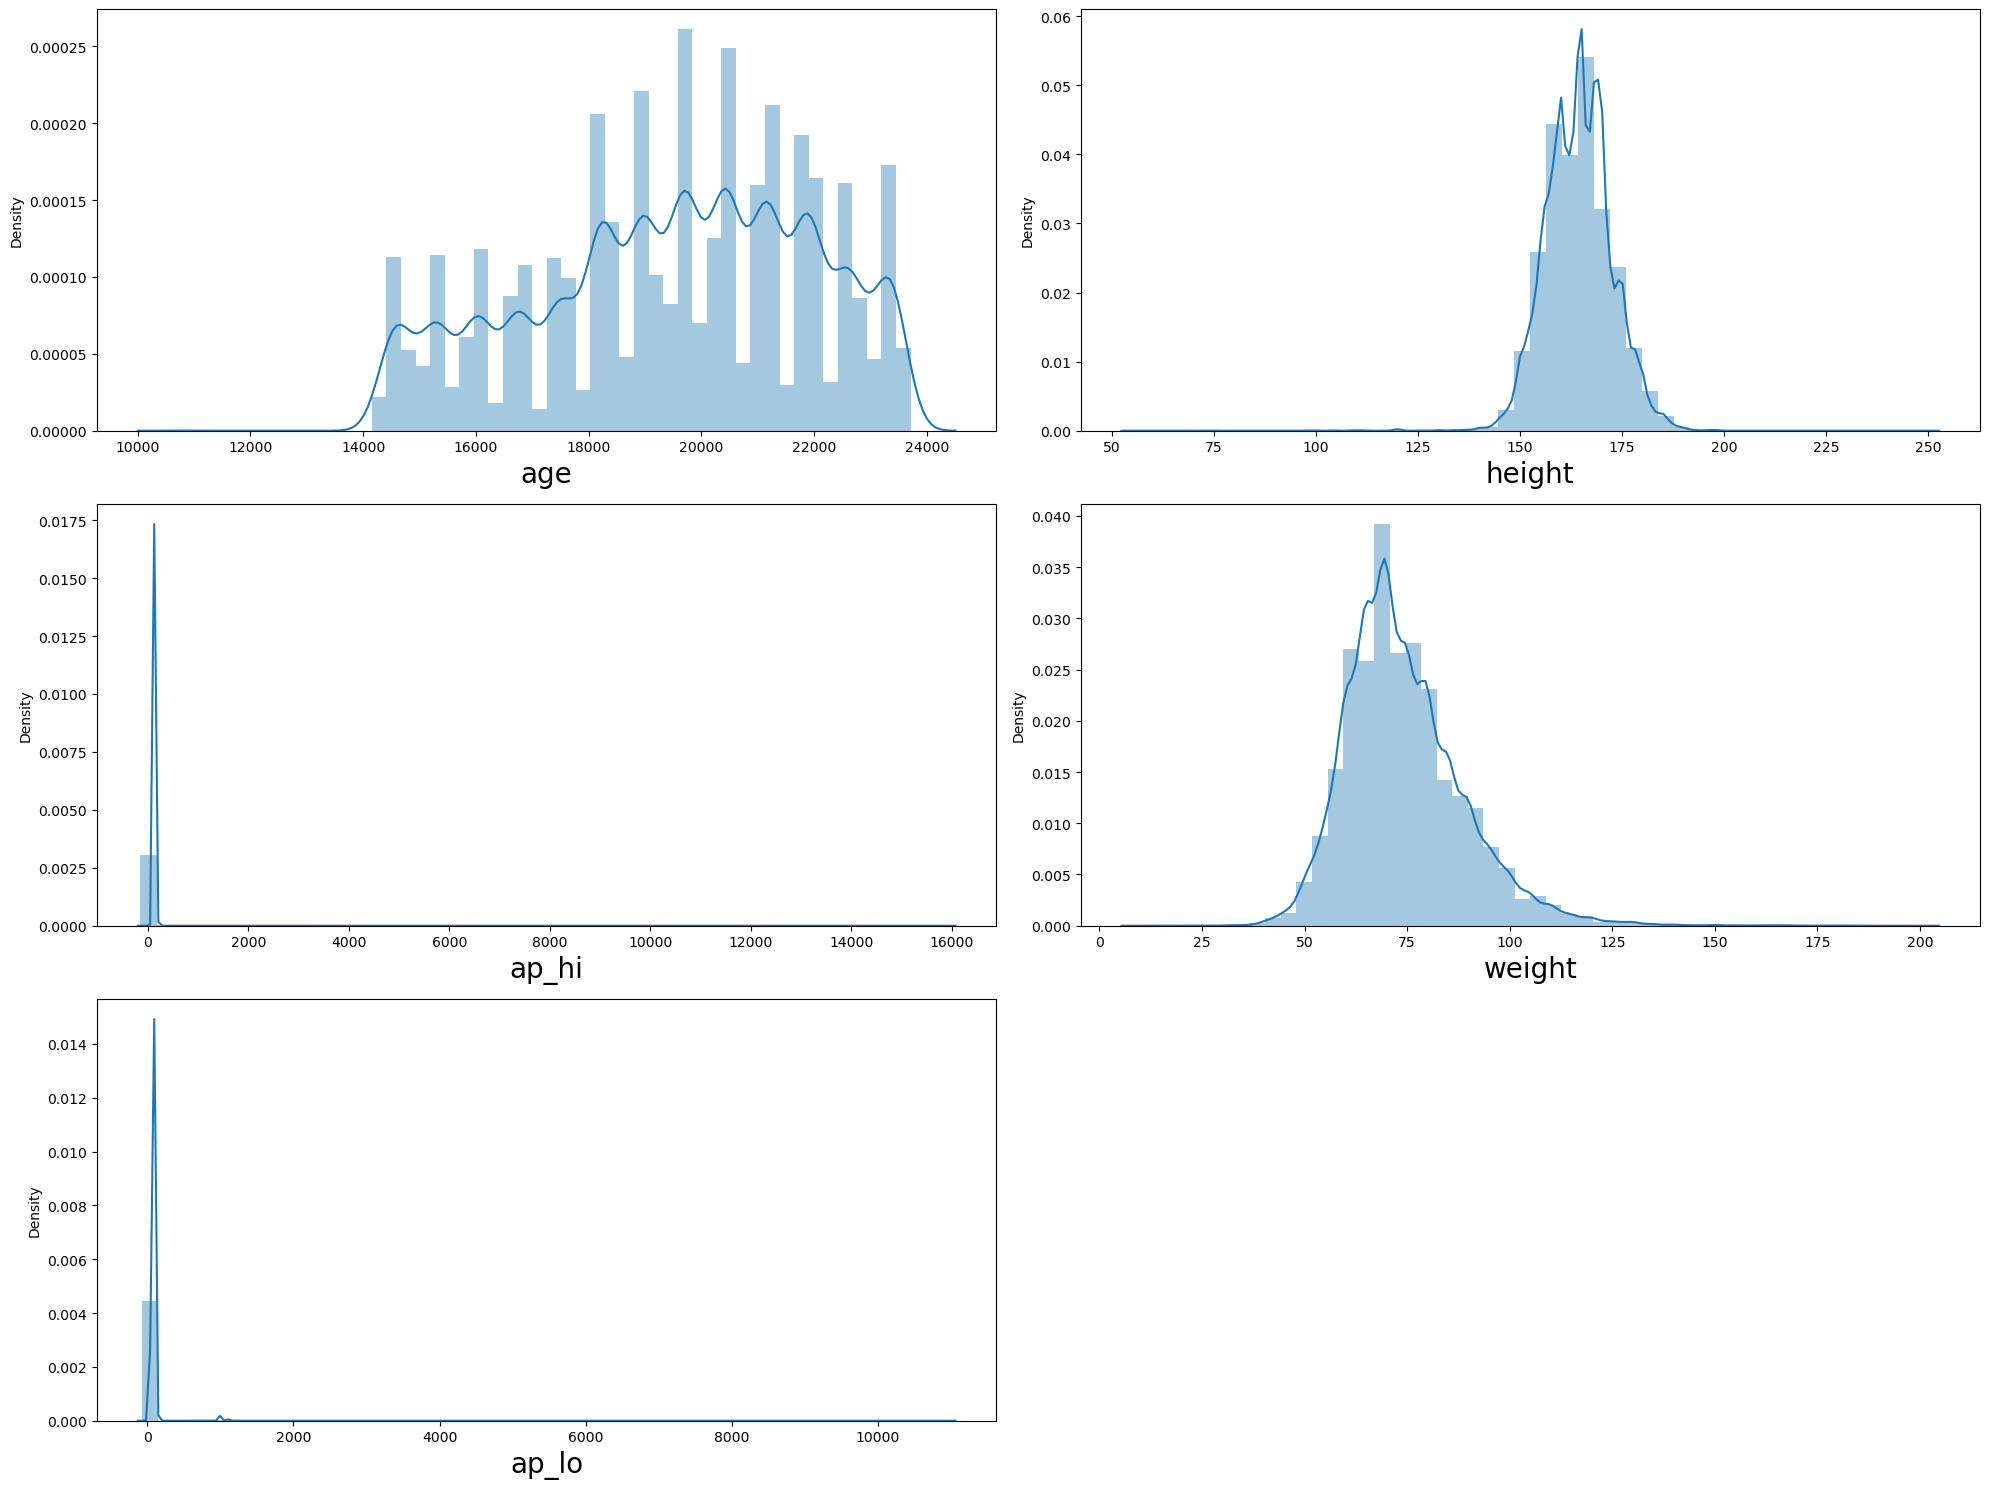

In [17]:
plt.figure(figsize=(20,15))
plotnumber=1
for column in df[['age','height','ap_hi','weight','ap_lo']]:
    if plotnumber<=6:
        ax= plt.subplot(3,2,plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column,fontsize=20)

    plotnumber+=1
plt.tight_layout()


In [18]:
# with standardization 3 lets see the stats
# from scipy import stats
# Zscore= (x=mean)/std   =>you have seen this in standard scaler

### z = (x -mean)/std
from scipy.stats import zscore
z_score = zscore(df[['age','height','ap_hi','weight','ap_lo']])
abs_z_score = np.abs(z_score) # Apply the formula and get the scaled data
filtering_entry = (abs_z_score < 3).all(axis=1)
df = df[filtering_entry]
df.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000,67360.000000
mean,19466.779053,1.347268,164.374555,73.566278,126.164430,81.286001,1.362010,1.223575,0.087159,0.053281,0.803949,0.492815
std,2467.040240,0.476105,7.690310,13.195627,17.860035,10.236086,0.677075,0.569505,0.282069,0.224595,0.397011,0.499952
min,14275.000000,1.000000,140.000000,32.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17660.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19702.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21324.000000,2.000000,170.000000,81.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,188.000000,117.000000,401.000000,602.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,22469,1,155,69.0,130,80,2,2,0,0,1,0
1,14648,1,163,71.0,110,70,1,1,0,0,1,1
2,21901,1,165,70.0,120,80,1,1,0,0,1,0
3,14549,2,165,85.0,120,80,1,1,1,1,1,0
4,23393,1,155,62.0,120,80,1,1,0,0,1,0


In [ ]:
# Check how much skewness we removed

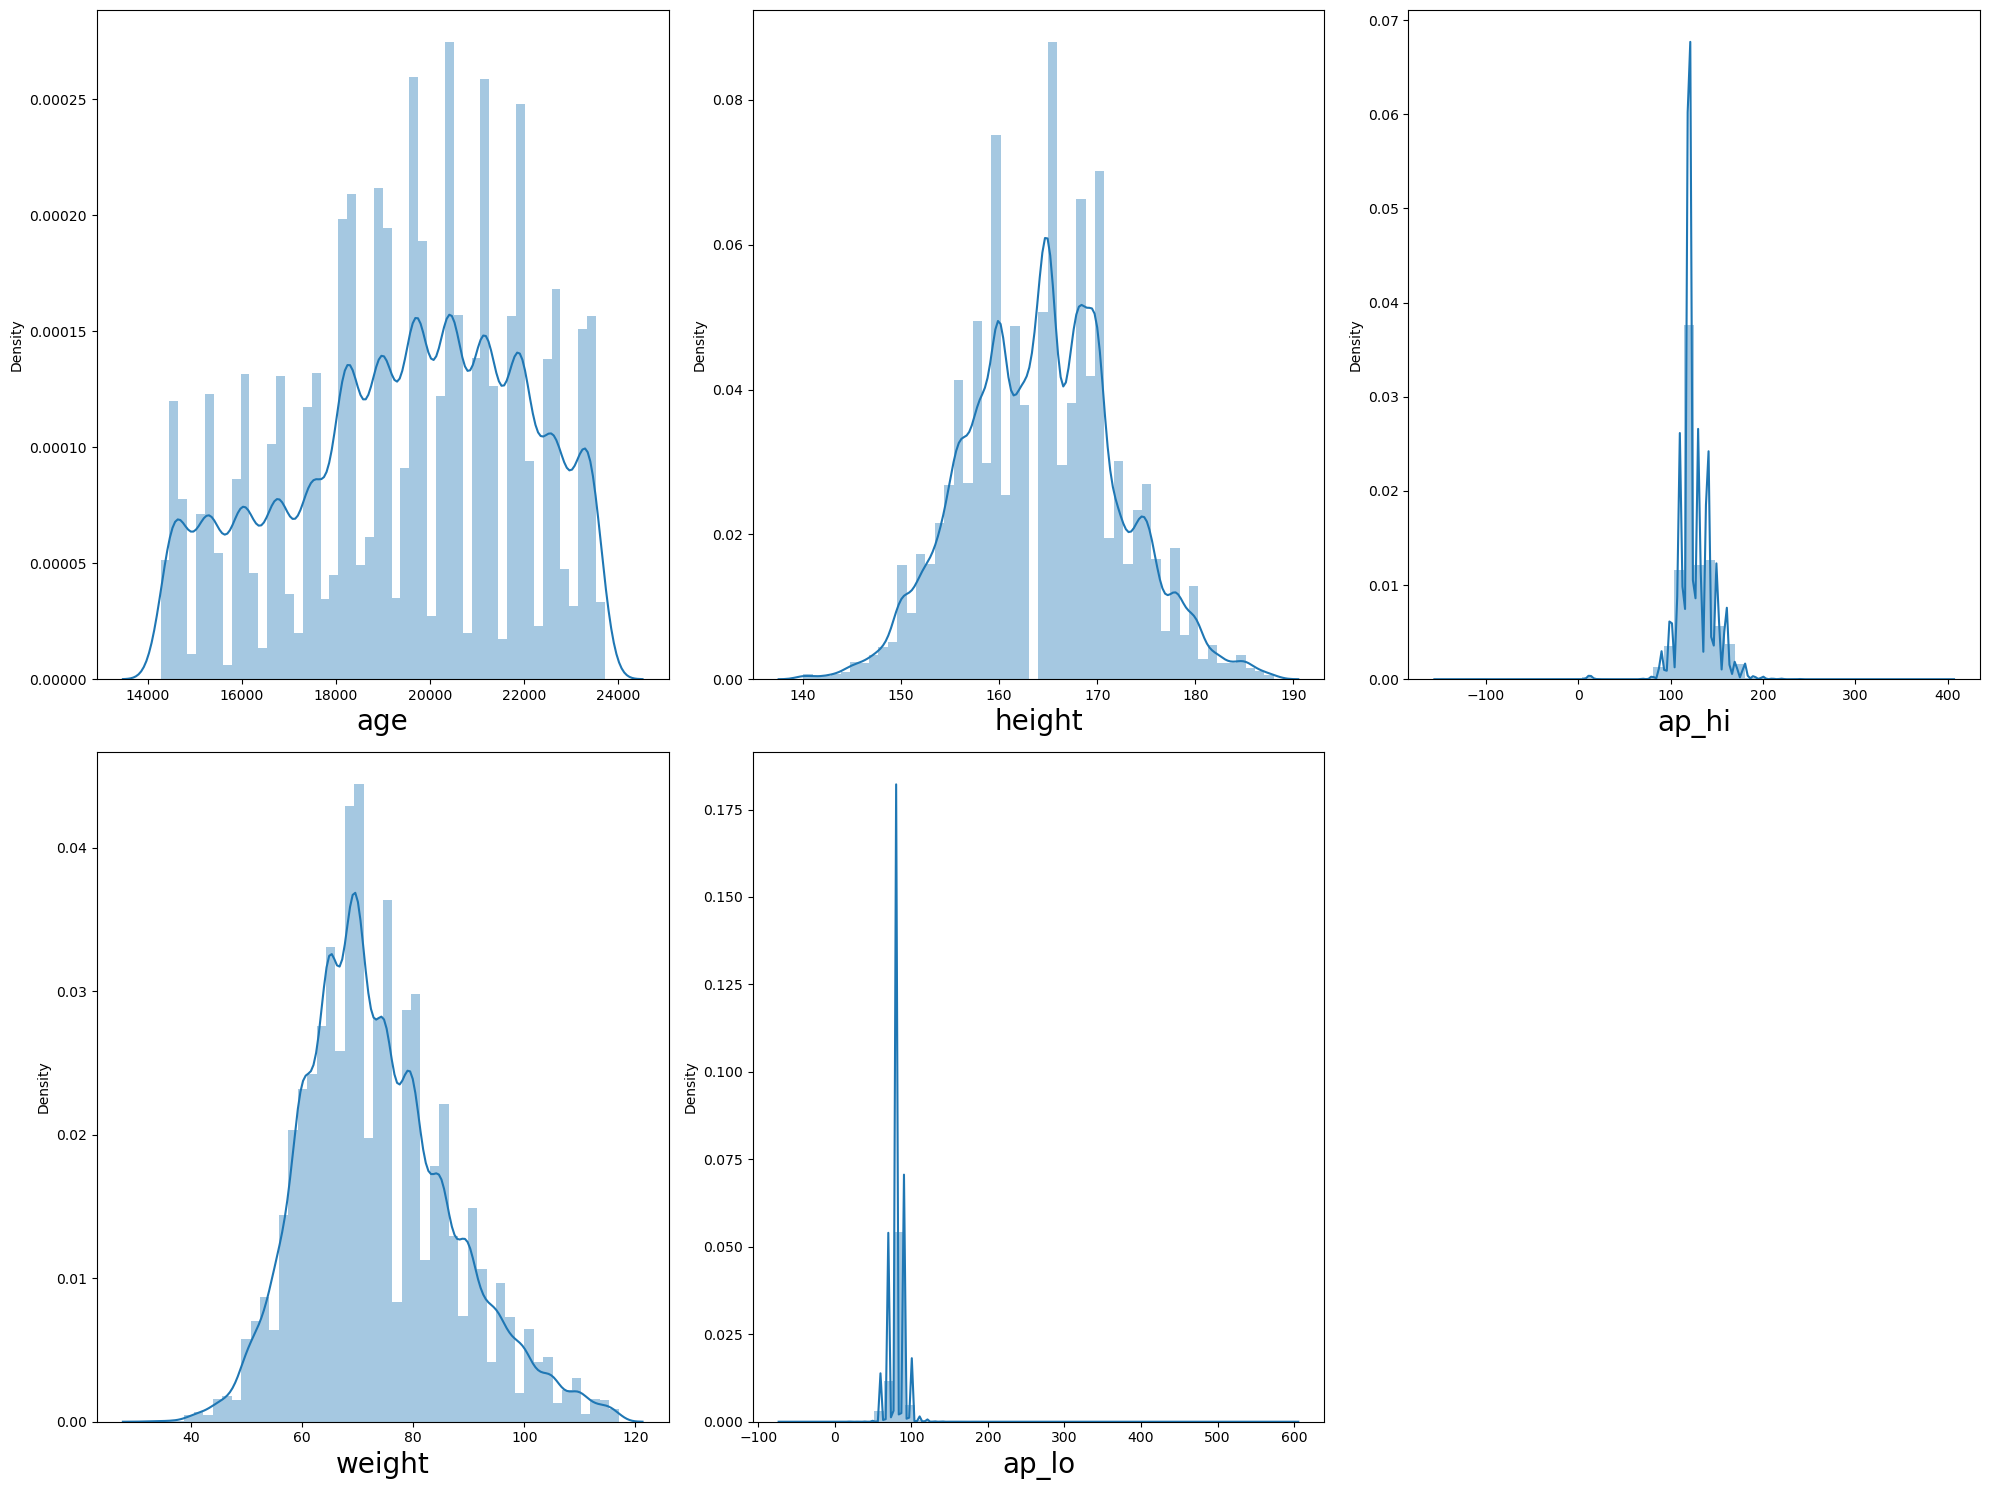

In [24]:
plt.figure(figsize=(20,15))
plotnumber = 1

for column in df[['age','height','ap_hi','weight','ap_lo']]:
    if plotnumber<=6:
        ax=plt.subplot(2,3,plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [25]:
df.shape

(67360, 12)

In [22]:
# cannot make out much from the above plots. lets build model
x = df.drop(columns=['cardio'], axis=1)
y= df['cardio']

# Split into train test data set

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.30, random_state= 41)

# Model confidence/accuracy

In [27]:
# wrire one function and call as many times to check accuracy_score of different models
def metric_score(clf,x_train,x_test,y_train,y_test, train=True):

    if train:
        y_pred = clf.predict(x_train)
        print("\n=======================Train Result=========================")
        print(f"Accuracy Score: {accuracy_score(y_train,y_pred) *100:.2f}%")
    elif train==False:
        pred = clf.predict(x_test)
        print("\n=======================Test Result=========================")
        print(f"Accuracy Score: {accuracy_score(y_test,pred) *100:.2f}%")
        print ('\n \n Test Classification Report \n', classification_report(y_test,pred,digits=2)) ## Model confidence/accuracy

In [28]:
# Initiate RandomForestClassifier and train
random_clf = RandomForestClassifier()

# Train the model
random_clf.fit(x_train,y_train)

RandomForestClassifier()

In [29]:
# Call the function and pass dataset to check train and test score

metric_score(random_clf,x_train,x_test,y_train,y_test, train=True)  # This is for training score
metric_score(random_clf,x_train,x_test,y_train,y_test, train=False)  # This is for testing score


=======================Train Result=========================
Accuracy Score: 99.99%

=======================Test Result=========================
Accuracy Score: 71.09%

 
 Test Classification Report 
               precision    recall  f1-score   support

           0       0.71      0.73      0.72     10243
           1       0.71      0.69      0.70      9965

    accuracy                           0.71     20208
   macro avg       0.71      0.71      0.71     20208
weighted avg       0.71      0.71      0.71     20208



In [30]:
# Let's tune the parameters using GridSearchCV

In [31]:
# RandomForestClassifier
params = {'n_estimators':[13,15],
          'criterion':['entropy','gini'],
          'max_depth':[10,15],
          'min_samples_split':[10,11],
          'min_samples_leaf':[5,6]
         }
grd = GridSearchCV(random_clf,param_grid=params)
grd.fit(x_train,y_train)
print ('best_params =>', grd.best_params_)

best_params => {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 15}


In [32]:
random_clf = grd.best_estimator_     # reinstantiating with best params
random_clf.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=6, min_samples_split=10,
                       n_estimators=15)

In [33]:
# Call the function and pass dataset to check train and test score

metric_score(random_clf,x_train,x_test,y_train,y_test, train=True)  # This is for training score
metric_score(random_clf,x_train,x_test,y_train,y_test, train=False)  # This is for testing score


=======================Train Result=========================
Accuracy Score: 74.93%

=======================Test Result=========================
Accuracy Score: 73.49%

 
 Test Classification Report 
               precision    recall  f1-score   support

           0       0.72      0.79      0.75     10243
           1       0.76      0.68      0.72      9965

    accuracy                           0.73     20208
   macro avg       0.74      0.73      0.73     20208
weighted avg       0.74      0.73      0.73     20208



# Let's plot ROC AUC curve to choose best model

In [34]:
# Plot ROC/AUC for multiple models without hyperparams tuning.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score,auc


In [35]:
# Load your data and split it into training and testing sets
x= df.drop(columns=['cardio'],axis=1)
y = df['cardio']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25, random_state=52)

# train your models
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
kn = KNeighborsClassifier()

# let's check ROC AUC Curve for the fitted model


Threshold of  Logistic regression [1.99626576e+00 9.96265758e-01 9.96241355e-01 ... 4.33563164e-03
 4.25102161e-03 5.38030109e-05]
Threshold of  Random Forest [2.         1.         0.99       0.98       0.97       0.96
 0.95       0.94       0.93       0.92       0.91       0.9
 0.89       0.88666667 0.88       0.87       0.86833333 0.86
 0.85       0.84       0.835      0.83       0.82       0.81
 0.8        0.79       0.78       0.77166667 0.77       0.76
 0.754      0.75       0.74       0.73616667 0.73       0.72
 0.71       0.7        0.69       0.68       0.675      0.67
 0.66       0.655      0.65       0.64       0.63       0.6225
 0.62       0.6175     0.61       0.6        0.59       0.585
 0.58       0.57       0.565      0.56333333 0.56       0.55
 0.545      0.54       0.53       0.52       0.51633333 0.51
 0.5075     0.5        0.49       0.48       0.47833333 0.47333333
 0.47       0.46       0.45       0.445      0.44       0.43
 0.42       0.41       0.4        0.3983

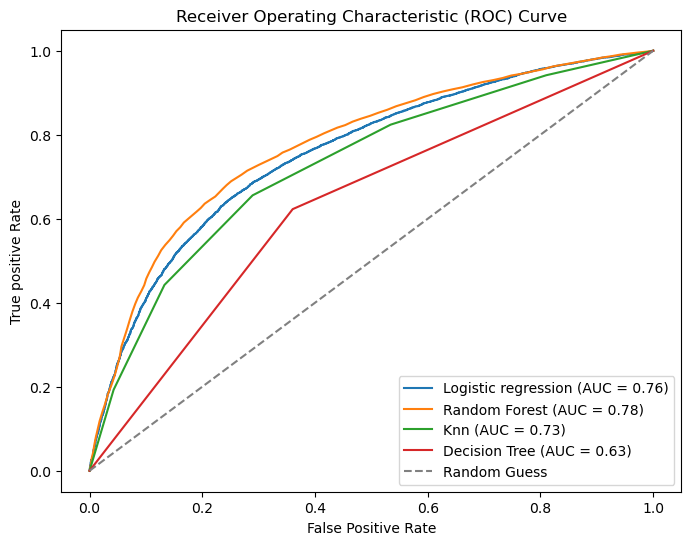

In [36]:
models={'Logistic regression': lr, 'Random Forest':rf, 'Knn':kn, 'Decision Tree':dt}
# calculate the ROC curves and AUC scores for each model
plt.figure(figsize=(8,6))
for name,model in models.items():   # Reading key and values from the items
    model.fit(x_train,y_train)      # Each model training
    y_prob = model.predict_proba(x_test)[:,1] #Predict probe of each model
    fpr,tpr, _ =roc_curve(y_test,y_prob)  # finding false and true positive rate(' _ ' is threshold)
    print('Threshold of ',name, _)
    roc_auc = auc(fpr,tpr)    # auc score of each model captured
    # Plot the ROC curve
    plt.plot(fpr,tpr,label='{} (AUC = {:.2f})'.format(name,roc_auc))

# Add labels and legend to the plot
plt.plot([0,1], [0,1], linestyle='--', color='grey', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Show the plot
plt.show()
         
